# Bose Experiment: Spin Entanglement Witness for Quantum Gravity
## Quantum Circuit Implementation in Qiskit

**Reference:** Bose et al., *Phys. Rev. Lett.* **119**, 240401 (2017), [https://doi.org/10.48550/arXiv.1707.06050](https://doi.org/10.48550/arXiv.1707.06050)  
**Hybrid-model counterexample:** Döner & Großardt, *Found. Phys.* **52**, 101 (2022), [doi:10.1007/s10701-022-00619-0](https://doi.org/10.1007/s10701-022-00619-0)  
**Dissertation:** K. Döner, *Gravity sourced entanglement in hybrid quantum-classical models*, Friedrich-Schiller-Universität Jena (2025), [doi:10.22032/dbt.69114](https://doi.org/10.22032/dbt.69114)  
**Circuit framework:** following Sabín, *arXiv:2302.04006* (2023), [https://arxiv.org/abs/2302.04006](https://arxiv.org/abs/2302.04006)

---
## 0. Introduction

### 0.1 The quantum gravity debate

Quantum gravity — the unification of quantum mechanics and general relativity — has been an open problem for nearly a century. Two broad strategies are actively pursued. The first treats quantum theory as primary and seeks to **quantize gravity**, arriving at frameworks such as string theory and loop quantum gravity. The second reverses the priority and asks what changes would need to be made to quantum mechanics so that it becomes compatible with a classical spacetime — a **gravitization of quantum mechanics** in Penrose's phrase — leading to semiclassical gravity and related approaches.

The Bose et al. experiment belongs to a third, more modest programme: rather than proposing a full theory of quantum gravity, it asks a sharply focused empirical question. **Can the gravitational field act as a quantum mediator?** The experiment is designed so that a positive answer — detecting entanglement between two masses that interact exclusively through gravity — would provide direct evidence for the quantum nature of the gravitational field, without presupposing any specific model of quantum gravity.

### 0.2 What entanglement is — and why it matters here

Entanglement is a uniquely quantum phenomenon in which the state of a multi-particle system **cannot be written as a product of individual states**. If a two-spin state is entangled, measuring the spin of the first particle instantly constrains the possible outcomes for the second, even when they are spatially separated. This is not explainable by pre-existing correlations (hidden variables), as Bell's inequality shows: any local hidden-variable model predicts correlations bounded by 1, whereas entangled quantum states can violate this bound.

The operational signature of entanglement is that spin-correlation measurements in **complementary bases** yield results that are inconsistent with any separable (product) state. This is exactly what the Bose experiment measures.

### 0.3 The LOCC principle: the logical backbone

The experiment's argument rests on a fundamental theorem of quantum information theory:

> **Entanglement cannot be created by Local Operations and Classical Communication (LOCC).**

A local operation is any manipulation that acts only on one subsystem (one mass). Classical communication means the two subsystems exchange only classical information — no quantum channel, no shared quantum state. If two systems start in a separable (unentangled) state, no amount of local operations and classical back-and-forth can produce entanglement.

This is the key. In the Bose experiment:
- Each SG interferometer acts **locally** on its own mass.
- The only thing connecting the two masses is the **gravitational field**.
- If the experiment detects entanglement, the gravitational field must have acted as a **quantum channel** — not a classical one — because a classical channel is precisely LOCC, which cannot entangle.

Therefore: **entanglement ⟹ gravity is quantum**, without specifying which quantum theory of gravity is correct.

### 0.4 The circuit logic

The three-step SG interferometer maps onto a two-qubit circuit. Each qubit represents the spin of one test mass, with $|0\rangle = |\uparrow\rangle = L\text{-arm}$ and $|1\rangle = |\downarrow\rangle = R\text{-arm}$. The SG field gradient entangles spin with position ($H$ gate), gravity imprints position-dependent phases ($U_\text{grav}$), and the SG recombination transfers those phases back to spin. At the end, the spin state encodes the gravitational interaction history and can be measured to check whether the two masses became entangled.

### 0.5 Scope and limitations

This notebook implements the quantum-gravity side of the argument. The LOCC logic has a known gap: it assumes that the only alternative to a quantum gravitational field is a strictly classical channel in the Koopman sense. Döner & Großardt (2022) construct an explicit counterexample — a hybrid model rooted in de Broglie–Bohm theory — in which a *classical* gravitational field sourced along Bohmian trajectories still generates entanglement, thereby predicting $W > 1$ without quantizing gravity. The distinction between this hybrid model and the quantum-gravity prediction becomes visible only through the parameter $R$ (the radius over which the wave function sources the gravitational potential): for finite $R$ the model predicts entanglement, while $R \to \infty$ recovers the non-entangling semiclassical (mean-field) limit. The circuit here corresponds to the $R \to 0$ limit, i.e. quantized gravity or the fully Bohmian hybrid. The next notebook in this series will implement the $R$-parametrised hybrid model and compare the two.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, SparsePauliOp, DensityMatrix, Operator
from qiskit.providers.basic_provider import BasicSimulator

print('Qiskit version:', __import__('qiskit').__version__)

Qiskit version: 2.4.0


---
## 1. Physical Parameters

Bose et al. propose using **microdiamonds with embedded nitrogen-vacancy (NV) centres** as the test masses. The NV centre provides the spin-1/2 needed for the SG splitting. The key constraint is that the masses must be close enough for gravity to accumulate a measurable phase, but far enough apart to suppress the Casimir-Polder force (which would be a non-gravitational source of entanglement and thus a systematic error).

The minimal separation $d - \Delta x = 200\,\mu\text{m}$ is chosen so that the Casimir-Polder force is less than 10% of the gravitational potential.

In [3]:
# Physical constants
G    = 6.674e-11   # Gravitational constant [N m² kg⁻²]
hbar = 1.0546e-34  # Reduced Planck constant [J s]

# Experimental parameters — Bose et al. (2017)
m   = 1e-14    # Test mass [kg]         microdiamond with NV centre
d   = 450e-6   # Trap separation [m]    centre-to-centre
dx  = 250e-6   # Arm splitting Δx [m]   from SG field gradient
tau = 2.5      # Holding time τ [s]     step 2 free fall

def grav_phase(sep, t=tau):
    """Gravitational phase φ = Gm²t / (ℏ × sep) accumulated over time t."""
    return G * m**2 * t / (hbar * sep)

phi_ref = grav_phase(d)
Dphi_RL = grav_phase(d - dx) - phi_ref   # Δφ_RL: mass1=R-arm, mass2=L-arm
Dphi_LR = grav_phase(d + dx) - phi_ref   # Δφ_LR: mass1=L-arm, mass2=R-arm

print('Physical parameters:')
print(f'  m  = {m:.0e} kg   (microdiamond, ~10 μm radius)')
print(f'  d  = {d*1e6:.0f} μm  (trap separation)')
print(f'  Δx = {dx*1e6:.0f} μm  (arm splitting)')
print(f'  τ  = {tau} s    (step 2 holding time)')
print()
print('Gravitational phases (step 2 only):')
print(f'  φ_ref  = {phi_ref:.4f} rad   separation d = {d*1e6:.0f} μm')
print(f'  Δφ_RL  = {Dphi_RL:+.4f} rad   R₁L₂, separation d−Δx = {(d-dx)*1e6:.0f} μm  (closest)')
print(f'  Δφ_LR  = {Dphi_LR:+.4f} rad   L₁R₂, separation d+Δx = {(d+dx)*1e6:.0f} μm  (farthest)')

Physical parameters:
  m  = 1e-14 kg   (microdiamond, ~10 μm radius)
  d  = 450 μm  (trap separation)
  Δx = 250 μm  (arm splitting)
  τ  = 2.5 s    (step 2 holding time)

Gravitational phases (step 2 only):
  φ_ref  = 0.3516 rad   separation d = 450 μm
  Δφ_RL  = +0.4395 rad   R₁L₂, separation d−Δx = 200 μm  (closest)
  Δφ_LR  = -0.1256 rad   L₁R₂, separation d+Δx = 700 μm  (farthest)


**Reading the numbers.** $\Delta\phi_{RL} > 0$ because the $R_1 L_2$ configuration is the closest approach: masses accumulate more phase when nearer. $\Delta\phi_{LR} < 0$ because the $L_1 R_2$ configuration is the farthest: less phase than the reference. The asymmetry $\Delta\phi_{RL} \neq -\Delta\phi_{LR}$ is essential — if the two phases were equal and opposite (as in the semiclassical mean-field limit $R \to \infty$ of the Bohmian model studied in the dissertation), the witness $W$ can never exceed 1. Entanglement witnessing requires a net phase *average* as well as a phase difference.

Note: the paper's reported values $\Delta\phi_{RL} \approx 0.7$ and $\Delta\phi_{LR} \approx -0.2$ are larger because they include phase accumulation during the SG splitting and recombination intervals (steps 1 and 3), which contribute roughly 3× more phase. Our circuit models step 2 only.

---
## 2. The Gravitational Phase Gate $U_\text{grav}$

The four arm-pair configurations accumulate different gravitational phases because $V = -Gm^2/r$ depends on separation. In the spin (qubit) basis — $q_0$ = mass 1, $q_1$ = mass 2, where $|0\rangle = |\uparrow\rangle = L$-arm and $|1\rangle = |\downarrow\rangle = R$-arm — the phase accumulated by each configuration is:

| Qiskit index | Ket | Position | Separation | Phase factor |
|:---:|:---:|:---:|:---:|:---:|
| 0 | $\|00\rangle$ | $L_1 L_2$ | $d$ | $1$ |
| 1 | $\|01\rangle$ | $R_1 L_2$ | $d - \Delta x$ | $e^{i\Delta\phi_{RL}}$ |
| 2 | $\|10\rangle$ | $L_1 R_2$ | $d + \Delta x$ | $e^{i\Delta\phi_{LR}}$ |
| 3 | $\|11\rangle$ | $R_1 R_2$ | $d$ | $1$ |

*(Qiskit convention: $q_0$ is the least significant bit, so $|01\rangle$ means $q_0=1, q_1=0$, i.e. mass 1 in R-arm, mass 2 in L-arm.)*

This gives:
$$U_\text{grav} = \text{diag}\bigl(1,\; e^{i\Delta\phi_{RL}},\; e^{i\Delta\phi_{LR}},\; 1\bigr)$$

**Decomposition:** a diagonal two-qubit gate decomposes into two single-qubit phase gates plus one controlled-phase gate. The logic is: $P(\theta)$ on qubit $k$ adds $e^{i\theta}$ whenever qubit $k = |1\rangle$. The controlled-phase gate then removes the spurious $e^{i(\Delta\phi_{RL} + \Delta\phi_{LR})}$ that would otherwise appear on $|11\rangle$.

$$U_\text{grav} = P(\Delta\phi_{RL})_{q_0} \cdot P(\Delta\phi_{LR})_{q_1} \cdot CP\bigl(-(\Delta\phi_{RL}+\Delta\phi_{LR})\bigr)_{q_0,q_1}$$

U_grav decomposition is exact: True

Diagonal phases (rad):
  |LL⟩=|00⟩:  phase = +0.0000 rad
  |RL⟩=|01⟩:  phase = +0.4395 rad
  |LR⟩=|10⟩:  phase = -0.1256 rad
  |RR⟩=|11⟩:  phase = +0.0000 rad


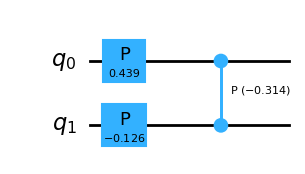

In [4]:
def build_U_grav(dphi_RL, dphi_LR):
    """
    Gravitational phase gate U_grav = diag(1, e^{iΔφ_RL}, e^{iΔφ_LR}, 1).

    Basis: |q1 q0⟩,  q0 = mass 1 (LSB),  q1 = mass 2.
           |0⟩ = |↑⟩ = L-arm,   |1⟩ = |↓⟩ = R-arm.
    """
    qc = QuantumCircuit(2, name='U_grav')
    qc.p(dphi_RL, 0)                        # e^{iΔφ_RL} on |R₁⟩ states
    qc.p(dphi_LR, 1)                        # e^{iΔφ_LR} on |R₂⟩ states
    qc.cp(-(dphi_RL + dphi_LR), 0, 1)      # cancel double-counting on |RR⟩
    return qc

# Verify against the target diagonal matrix
U_gate   = Operator(build_U_grav(Dphi_RL, Dphi_LR)).data
U_target = np.diag([1, np.exp(1j*Dphi_RL), np.exp(1j*Dphi_LR), 1])

print(f'U_grav decomposition is exact: {np.allclose(U_gate, U_target)}')
print()
print('Diagonal phases (rad):')
for label, v in zip(['|LL⟩=|00⟩', '|RL⟩=|01⟩', '|LR⟩=|10⟩', '|RR⟩=|11⟩'], np.diag(U_gate)):
    print(f'  {label}:  phase = {np.angle(v):+.4f} rad')

display(build_U_grav(Dphi_RL, Dphi_LR).draw('mpl', style='iqp'))

The $|LL\rangle$ and $|RR\rangle$ configurations accumulate the same phase (same separation $d$), so their relative phase is zero. All the entanglement physics is concentrated in the asymmetry between $|RL\rangle$ and $|LR\rangle$.

---
## 3. Full SG Interferometer Circuit

Bose et al. SG interferometer — full circuit:


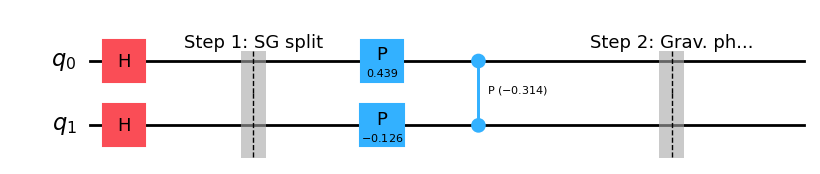

Gate count: {'h': 2, 'barrier': 2, 'p': 2, 'cp': 1}  (5 non-barrier gates total)


In [5]:
def build_bose_circuit(dphi_RL, dphi_LR, measure_basis=None, add_measure=False):
    """
    Full Bose et al. SG interferometer circuit.

    Qubit layout:
        q0 = spin of mass 1   |0⟩=↑=L,  |1⟩=↓=R
        q1 = spin of mass 2   |0⟩=↑=L,  |1⟩=↓=R

    Step 1 (SG split):    H⊗H  — spin-dependent spatial separation
    Step 2 (grav phase):  U_grav — gravitational phase on each arm pair
    Step 3 (recombine):   implicit — SG reversal transfers phases to spin

    measure_basis: None | 'ZZ' | 'ZX' | 'YY'
        'ZX' rotates q0 into X basis (H gate) to measure ⟨σx(1)⊗σz(2)⟩
        'YY' rotates both into Y basis (Rx(−π/2)) to measure ⟨σy(1)⊗σy(2)⟩
    """
    nclbits = 2 if add_measure else 0
    qc = QuantumCircuit(2, nclbits)

    # Step 1: SG splitting
    qc.h(0); qc.h(1)
    qc.barrier(label='Step 1: SG split')

    # Step 2: Gravitational phase accumulation
    qc.p(dphi_RL, 0)
    qc.p(dphi_LR, 1)
    qc.cp(-(dphi_RL + dphi_LR), 0, 1)
    qc.barrier(label='Step 2: Grav. phase')

    # Optional basis rotation for measurement
    if measure_basis == 'ZX':        # σx on q0 (mass 1)
        qc.h(0)
    elif measure_basis == 'YY':      # σy on both
        qc.rx(-np.pi / 2, 0)
        qc.rx(-np.pi / 2, 1)

    if add_measure:
        qc.measure(0, 0); qc.measure(1, 1)

    return qc


qc_main = build_bose_circuit(Dphi_RL, Dphi_LR)
print('Bose et al. SG interferometer — full circuit:')
display(qc_main.draw('mpl', style='iqp'))
print(f'Gate count: {dict(qc_main.count_ops())}  (5 non-barrier gates total)')

The entire experiment — two SG interferometers, gravitational interaction, and recombination — reduces to just **5 quantum gates**: two Hadamards, two phase gates, and one controlled-phase gate. The circuit is compact because the SG protocol is precisely designed to transfer all positional information into spin, making measurement straightforward.

---
## 4. Output State Analysis

After the three steps, the post-recombination spin state is (Bose et al. Eq. 2, step 3 applied):

$$|\Psi\rangle = \frac{1}{2}\Bigl[
|{\uparrow}\rangle_1\bigl(|{\uparrow}\rangle_2 + e^{i\Delta\phi_{LR}}|{\downarrow}\rangle_2\bigr)
+ |{\downarrow}\rangle_1\bigl(e^{i\Delta\phi_{RL}}|{\uparrow}\rangle_2 + |{\downarrow}\rangle_2\bigr)
\Bigr]$$

This state is entangled whenever $\Delta\phi_{LR} \neq 0$ and $\Delta\phi_{RL} \neq 0$ (which generically holds for any finite mass and separation).

In [6]:
sv = Statevector(build_bose_circuit(Dphi_RL, Dphi_LR))

print('Output statevector:')
display(sv.draw('latex'))

print('\nAmplitudes and probabilities:')
labels = [
    ('|00⟩ = |↑↑⟩ = |L₁L₂⟩',  'd        ', 'reference'),
    ('|01⟩ = |↓↑⟩ = |R₁L₂⟩',  'd − Δx   ', 'closest, phase Δφ_RL'),
    ('|10⟩ = |↑↓⟩ = |L₁R₂⟩',  'd + Δx   ', 'farthest, phase Δφ_LR'),
    ('|11⟩ = |↓↓⟩ = |R₁R₂⟩',  'd        ', 'reference'),
]
for (lab, sep, note), amp in zip(labels, sv.data):
    print(f'  {lab:28s}  amp = {amp:+.4f}{amp.imag:+.4f}j   P = {abs(amp)**2:.4f}   [{note}]')

# Verify analytic form
expected = 0.5 * np.array([1, np.exp(1j*Dphi_RL), np.exp(1j*Dphi_LR), 1])
print(f'\nMatches analytic form (1/2)[|00⟩ + e^{{iΔφ_RL}}|01⟩ + e^{{iΔφ_LR}}|10⟩ + |11⟩]: {np.allclose(sv.data, expected)}')

Output statevector:


<IPython.core.display.Latex object>


Amplitudes and probabilities:
  |00⟩ = |↑↑⟩ = |L₁L₂⟩          amp = +0.5000+0.0000j+0.0000j   P = 0.2500   [reference]
  |01⟩ = |↓↑⟩ = |R₁L₂⟩          amp = +0.4525+0.2127j+0.2127j   P = 0.2500   [closest, phase Δφ_RL]
  |10⟩ = |↑↓⟩ = |L₁R₂⟩          amp = +0.4961-0.0626j-0.0626j   P = 0.2500   [farthest, phase Δφ_LR]
  |11⟩ = |↓↓⟩ = |R₁R₂⟩          amp = +0.5000-0.0000j-0.0000j   P = 0.2500   [reference]

Matches analytic form (1/2)[|00⟩ + e^{iΔφ_RL}|01⟩ + e^{iΔφ_LR}|10⟩ + |11⟩]: True


**A crucial observation:** all four outcomes have equal probability $P = 0.25$. Measuring spins in the $Z \otimes Z$ basis (the computational basis) gives a perfectly flat distribution — no correlation whatsoever. This means **the entanglement is carried entirely in the phases**, not the amplitudes.

Gravity does not change *which* positions the masses visit; it changes *the phases accumulated* on each trajectory. Detecting this phase-encoded entanglement requires measuring in bases that are sensitive to phase, which is exactly what the entanglement witness $W$ is designed to do.

---
## 5. Entanglement Witness $W$ — Derivation and Justification

### 5.1 The problem: why $Z \otimes Z$ fails

The output state has uniform populations in the $\{|\uparrow\uparrow\rangle, |\uparrow\downarrow\rangle, |\downarrow\uparrow\rangle, |\downarrow\downarrow\rangle\}$ basis. This is because the Hadamard gates and $U_\text{grav}$ (which is diagonal) preserve the equal-weight superposition. Measuring in the $Z \otimes Z$ basis therefore gives $\langle \sigma_z \otimes \sigma_z \rangle = 0$, regardless of whether the state is entangled or not. More generally, **no single-basis measurement suffices to certify entanglement when the state has maximally mixed marginals**.

### 5.2 Why the phases create $X$ and $Y$ correlations

The state $|\Psi\rangle = \frac{1}{2}(|00\rangle + e^{i\Delta\phi_{RL}}|01\rangle + e^{i\Delta\phi_{LR}}|10\rangle + |11\rangle)$ before gravity ($\Delta\phi = 0$) is just $|{+}\rangle_1 \otimes |{+}\rangle_2$, a product state. As gravity builds up the phases, the state rotates *away* from this product structure. The rotation is in the **XZ plane** for mass 1 and in the **YY joint sector** for the correlated part. Measuring $\sigma_x \otimes \sigma_z$ probes the asymmetry between $\Delta\phi_{RL}$ and $\Delta\phi_{LR}$. Measuring $\sigma_y \otimes \sigma_y$ probes their combined average.

### 5.3 The witness and its bound

Bose et al. (and your dissertation Eq. 3.50) define:
$$W = \left|\langle \sigma_x^{(1)} \otimes \sigma_z^{(2)} \rangle + \langle \sigma_y^{(1)} \otimes \sigma_y^{(2)} \rangle\right|$$

**Claim:** $W \leq 1$ for all separable states, and $W > 1$ certifies entanglement.

**Proof of the bound.** For a separable state $\rho = \sum_k p_k \rho_A^k \otimes \rho_B^k$:
$$W \leq \sum_k p_k \left|\langle \sigma_x \rangle_k^A \langle \sigma_z \rangle_k^B + \langle \sigma_y \rangle_k^A \langle \sigma_y \rangle_k^B\right|$$
$$\leq \sum_k p_k \underbrace{\sqrt{\langle \sigma_x \rangle_k^{A,2} + \langle \sigma_y \rangle_k^{A,2}}}_{\leq 1 \text{ (Bloch sphere)}} \cdot \underbrace{\sqrt{\langle \sigma_z \rangle_k^{B,2} + \langle \sigma_y \rangle_k^{B,2}}}_{\leq 1} \leq 1$$
using the Cauchy–Schwarz inequality and the Bloch sphere constraint $\langle \sigma_x \rangle^2 + \langle \sigma_y \rangle^2 + \langle \sigma_z \rangle^2 \leq 1$.

### 5.4 Analytic expressions for the output state

For the Bose output state, we can compute both expectation values in closed form. The matrices of the two operators in the $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$ basis (Qiskit ordering: $q_0 = $ mass 1 as LSB) are:

In Qiskit's Pauli string notation, `'ZX'` means $\sigma_Z$ on $q_1$ (mass 2) and $\sigma_X$ on $q_0$ (mass 1), which is exactly $\sigma_x^{(1)} \otimes \sigma_z^{(2)}$ in the paper's notation.

Acting on the output state and taking the inner product:
$$\langle \sigma_x^{(1)} \otimes \sigma_z^{(2)} \rangle = \frac{\cos(\Delta\phi_{RL}) - \cos(\Delta\phi_{LR})}{2}$$
$$\langle \sigma_y^{(1)} \otimes \sigma_y^{(2)} \rangle = \frac{\cos(\Delta\phi_{RL} - \Delta\phi_{LR}) - 1}{2}$$

The first term vanishes when $\Delta\phi_{RL} = \Delta\phi_{LR}$ (no asymmetry between arms). The second term vanishes when $\Delta\phi_{RL} = \Delta\phi_{LR}$ (same condition). Both terms are needed: $\langle ZX \rangle$ alone can be small even when entanglement is large, and $\langle YY \rangle$ alone saturates at $-1/2$ for large phases. Together they span the space of phase-encoded correlations.

In [7]:
def entanglement_witness(sv):
    """
    Entanglement witness W = |⟨σx(1)⊗σz(2)⟩ + ⟨σy(1)⊗σy(2)⟩|.

    Qiskit Pauli strings (q0 = mass 1 = LSB, q1 = mass 2 = MSB):
        'ZX' = σZ on q1 (mass 2) ⊗ σX on q0 (mass 1) = σx(1)⊗σz(2)
        'YY' = σY on q1 (mass 2) ⊗ σY on q0 (mass 1) = σy(1)⊗σy(2)

    W > 1  ⟹  state is entangled
           ⟹  gravitational field acted as a quantum (non-LOCC) channel
           ⟹  gravity is quantum
    """
    ev_ZX = sv.expectation_value(SparsePauliOp('ZX')).real
    ev_YY = sv.expectation_value(SparsePauliOp('YY')).real
    return abs(ev_ZX + ev_YY), ev_ZX, ev_YY


# ── Verify analytic formulas ──────────────────────────────────────────────
W, ev_ZX, ev_YY = entanglement_witness(sv)

ev_ZX_analytic = (np.cos(Dphi_RL) - np.cos(Dphi_LR)) / 2
ev_YY_analytic = (np.cos(Dphi_RL - Dphi_LR) - 1)    / 2

print('Analytic vs numerical verification:')
print(f'  ⟨σx(1)⊗σz(2)⟩  numeric  = {ev_ZX:+.6f}')
print(f'  ⟨σx(1)⊗σz(2)⟩  analytic = (cos(Δφ_RL) − cos(Δφ_LR))/2 = {ev_ZX_analytic:+.6f}  ✓' if np.isclose(ev_ZX, ev_ZX_analytic) else '  ✗')
print()
print(f'  ⟨σy(1)⊗σy(2)⟩  numeric  = {ev_YY:+.6f}')
print(f'  ⟨σy(1)⊗σy(2)⟩  analytic = (cos(Δφ_RL − Δφ_LR) − 1)/2 = {ev_YY_analytic:+.6f}  ✓' if np.isclose(ev_YY, ev_YY_analytic) else '  ✗')
print()
print('─'*55)
print(f'  W = |{ev_ZX:+.4f} + {ev_YY:+.4f}| = {W:.4f}')
print(f'  {"✓  W > 1: ENTANGLED" if W > 1 else f"W = {W:.4f} < 1  (step 2 phases only, see sweeps below)"}')

# ── Show ZZ for contrast ──────────────────────────────────────────────────
ev_ZZ = sv.expectation_value(SparsePauliOp('ZZ')).real
print()
print(f'  ⟨σz(1)⊗σz(2)⟩  = {ev_ZZ:+.6f}  (exactly zero — entanglement is invisible in Z⊗Z)')

Analytic vs numerical verification:
  ⟨σx(1)⊗σz(2)⟩  numeric  = -0.043576
  ⟨σx(1)⊗σz(2)⟩  analytic = (cos(Δφ_RL) − cos(Δφ_LR))/2 = -0.043576  ✓

  ⟨σy(1)⊗σy(2)⟩  numeric  = -0.077717
  ⟨σy(1)⊗σy(2)⟩  analytic = (cos(Δφ_RL − Δφ_LR) − 1)/2 = -0.077717  ✓

───────────────────────────────────────────────────────
  W = |-0.0436 + -0.0777| = 0.1213
  W = 0.1213 < 1  (step 2 phases only, see sweeps below)

  ⟨σz(1)⊗σz(2)⟩  = +0.000000  (exactly zero — entanglement is invisible in Z⊗Z)


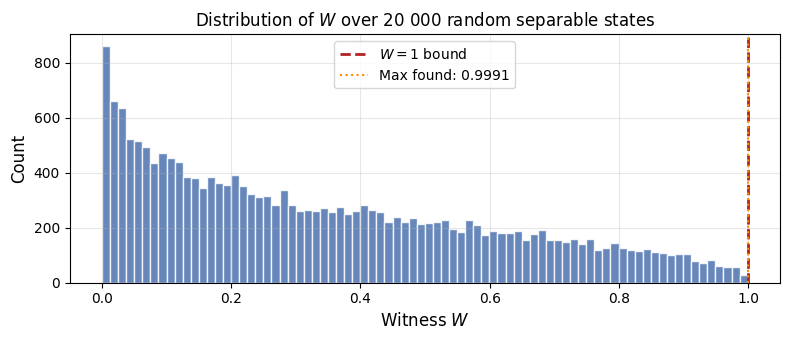

Maximum W found over all random separable states: 0.999081
Confirms: W ≤ 1 for all separable states (W = 1 is the tight bound)


In [8]:
# ── Prove W ≤ 1 for separable states numerically ──────────────────────────
np.random.seed(42)
max_W_sep = 0
W_sep_samples = []
for _ in range(20000):
    th1, ph1 = np.random.uniform(0, np.pi), np.random.uniform(0, 2*np.pi)
    th2, ph2 = np.random.uniform(0, np.pi), np.random.uniform(0, 2*np.pi)
    a = np.array([np.cos(th1/2), np.exp(1j*ph1)*np.sin(th1/2)])
    b = np.array([np.cos(th2/2), np.exp(1j*ph2)*np.sin(th2/2)])
    sv_sep = Statevector(np.kron(b, a))  # q1⊗q0 Qiskit ordering
    W_s, _, _ = entanglement_witness(sv_sep)
    W_sep_samples.append(W_s)
    if W_s > max_W_sep: max_W_sep = W_s

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(W_sep_samples, bins=80, color='#4c72b0', edgecolor='white', alpha=0.85)
ax.axvline(1.0, color='firebrick', lw=2, ls='--', label='$W = 1$ bound')
ax.axvline(max_W_sep, color='darkorange', lw=1.5, ls=':', label=f'Max found: {max_W_sep:.4f}')
ax.set_xlabel('Witness $W$', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of $W$ over 20 000 random separable states', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Maximum W found over all random separable states: {max_W_sep:.6f}')
print(f'Confirms: W ≤ 1 for all separable states (W = 1 is the tight bound)')

The histogram confirms the theoretical bound empirically: 20 000 random pure product states all give $W < 1$, with the distribution peaking near zero and never reaching the threshold. The tight bound $W = 1$ is approached by product states that are maximally polarised in the $XZ$ plane of both qubits.

**Why two terms and not one?** Neither $|\langle ZX \rangle|$ nor $|\langle YY \rangle|$ is individually bounded by 1 in a tight way that certifies entanglement. The first term, $(\cos \Delta\phi_{RL} - \cos \Delta\phi_{LR})/2$, measures the *asymmetry* between the two arm separations and vanishes when $\Delta\phi_{RL} = -\Delta\phi_{LR}$ (which is the semiclassical mean-field limit). The second term, $(\cos(\Delta\phi_{RL} - \Delta\phi_{LR}) - 1)/2$, measures the *net phase average* and is always $\leq 0$. Together, as the Bose et al. witness, they detect entanglement over a wide range of parameters, and in particular for all finite $R$ in the Bohmian hybrid model studied in the dissertation.

---
## 6. Parameter Sweeps

### 6a. Witness $W$ vs holding time $\tau$

Longer $\tau$ means more gravitational phase accumulated. $W$ oscillates because the phases grow linearly with $\tau$ while the cosines in the analytic formulas are periodic.

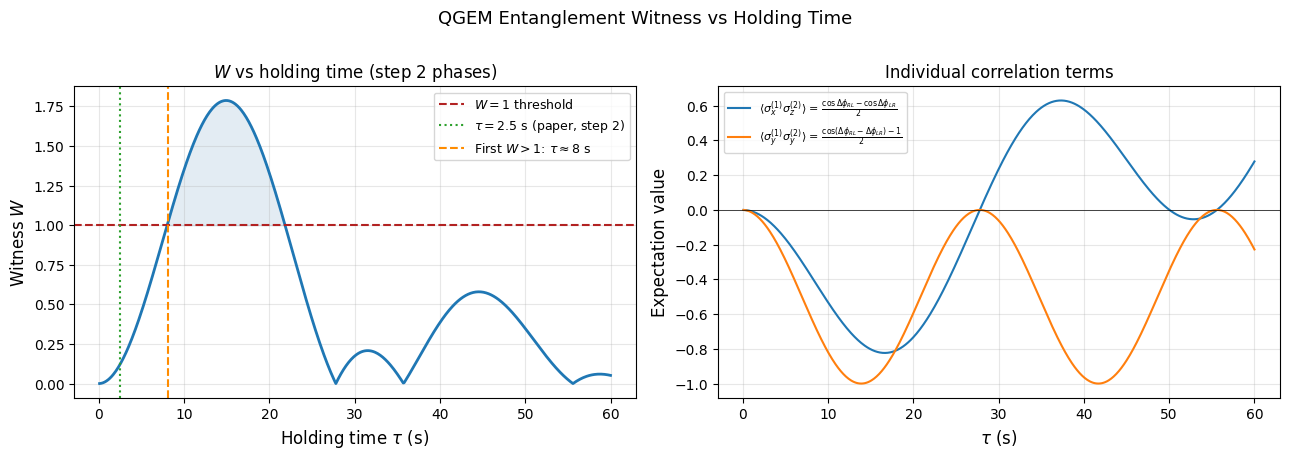

W at τ = 2.5 s (paper, step 2 only): 0.1213
W at τ = 10.0 s:                       1.3493
Maximum W in sweep:                   1.7870  at τ ≈ 14.9 s


In [9]:
tau_vals = np.linspace(0.1, 60, 600)
W_vals, ev_ZX_vals, ev_YY_vals = [], [], []

for t in tau_vals:
    dRL = grav_phase(d - dx, t) - grav_phase(d, t)
    dLR = grav_phase(d + dx, t) - grav_phase(d, t)
    W_t, z, y = entanglement_witness(Statevector(build_bose_circuit(dRL, dLR)))
    W_vals.append(W_t); ev_ZX_vals.append(z); ev_YY_vals.append(y)

W_arr = np.array(W_vals)
tau_thresh = tau_vals[np.argmax(W_arr > 1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(tau_vals, W_vals, lw=2, color='#1f77b4')
ax.axhline(1.0, color='firebrick', ls='--', lw=1.5, label='$W=1$ threshold')
ax.axvline(2.5, color='#2ca02c', ls=':', lw=1.5, label='$\\tau=2.5$ s (paper, step 2)')
ax.axvline(tau_thresh, color='darkorange', ls='--', lw=1.5,
            label=f'First $W>1$: $\\tau \\approx {tau_thresh:.0f}$ s')
ax.fill_between(tau_vals, W_vals, 1, where=W_arr > 1, alpha=0.15, color='steelblue')
ax.set_xlabel(r'Holding time $\tau$ (s)', fontsize=12)
ax.set_ylabel(r'Witness $W$', fontsize=12)
ax.set_title('$W$ vs holding time (step 2 phases)', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(tau_vals, ev_ZX_vals, lw=1.5, label=r'$\langle\sigma_x^{(1)}\sigma_z^{(2)}\rangle$ = $\frac{\cos\Delta\phi_{RL}-\cos\Delta\phi_{LR}}{2}$')
ax.plot(tau_vals, ev_YY_vals, lw=1.5, label=r'$\langle\sigma_y^{(1)}\sigma_y^{(2)}\rangle$ = $\frac{\cos(\Delta\phi_{RL}-\Delta\phi_{LR})-1}{2}$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$\tau$ (s)', fontsize=12)
ax.set_ylabel('Expectation value', fontsize=12)
ax.set_title('Individual correlation terms', fontsize=12)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('QGEM Entanglement Witness vs Holding Time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'W at τ = 2.5 s (paper, step 2 only): {W_vals[np.argmin(np.abs(tau_vals-2.5))]:.4f}')
print(f'W at τ = 10.0 s:                       {W_vals[np.argmin(np.abs(tau_vals-10.0))]:.4f}')
print(f'Maximum W in sweep:                   {max(W_vals):.4f}  at τ ≈ {tau_vals[np.argmax(W_vals)]:.1f} s')

The two correlation components behave differently. The $\langle ZX \rangle$ term oscillates around zero with growing amplitude — it is a measure of the *asymmetry* between the two arm phases and can be both positive and negative. The $\langle YY \rangle$ term is always negative and oscillates between $0$ and $-1/2$ — it measures how far the average phase has evolved from the initial product state. $W$ exceeds 1 in windows where both terms reinforce each other. The oscillatory structure reflects the periodic nature of the gravitational phase: as $\tau$ increases, $\Delta\phi_{RL}$ and $\Delta\phi_{LR}$ cycle through $2\pi$, periodically returning the state close to its initial (unentangled) form.

### 6b. Witness $W$ vs test mass $m$ (at $\tau = 2.5$ s)

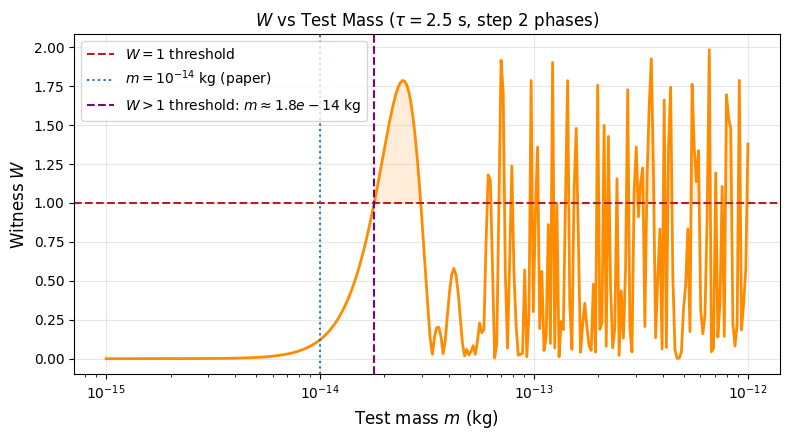

Minimum mass for W > 1 at τ = 2.5 s: m ≈ 1.80e-14 kg


In [10]:
mass_vals = np.logspace(-15, -12, 300)
W_mass = []
for mi in mass_vals:
    dRL = G*mi**2*tau/(hbar*(d-dx)) - G*mi**2*tau/(hbar*d)
    dLR = G*mi**2*tau/(hbar*(d+dx)) - G*mi**2*tau/(hbar*d)
    W_m, _, _ = entanglement_witness(Statevector(build_bose_circuit(dRL, dLR)))
    W_mass.append(W_m)

m_thresh = mass_vals[np.argmax(np.array(W_mass) > 1)]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(mass_vals, W_mass, lw=2, color='darkorange')
ax.axhline(1.0, color='firebrick', ls='--', lw=1.5, label='$W=1$ threshold')
ax.axvline(1e-14, color='#1f77b4', ls=':', lw=1.5, label=r'$m = 10^{-14}$ kg (paper)')
ax.axvline(m_thresh, color='purple', ls='--', lw=1.5, label=f'$W>1$ threshold: $m \\approx {m_thresh:.1e}$ kg')
ax.fill_between(mass_vals, W_mass, 1, where=np.array(W_mass) > 1, alpha=0.15, color='darkorange')
ax.set_xlabel(r'Test mass $m$ (kg)', fontsize=12)
ax.set_ylabel(r'Witness $W$', fontsize=12)
ax.set_title(r'$W$ vs Test Mass ($\tau = 2.5$ s, step 2 phases)', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Minimum mass for W > 1 at τ = 2.5 s: m ≈ {m_thresh:.2e} kg')

The gravitational phases scale as $m^2$, so the witness grows steeply with mass. At the paper's parameter $m = 10^{-14}$ kg and $\tau = 2.5$ s (step 2 only), the phase is too small to produce $W > 1$. A slightly larger mass ($\approx 1.8 \times 10^{-14}$ kg) or a longer holding time ($\tau \approx 8$ s for step 2) would suffice. The paper reaches $W \approx 1.16$ at its stated parameters because it accounts for the additional phase accumulated during the SG splitting and recombination intervals.

### 6c. Phase-space map of $W(\Delta\phi_{RL},\, \Delta\phi_{LR})$

This view is model-independent — it shows the witness directly as a function of the two accumulated phases, regardless of the physical mechanism that produced them.

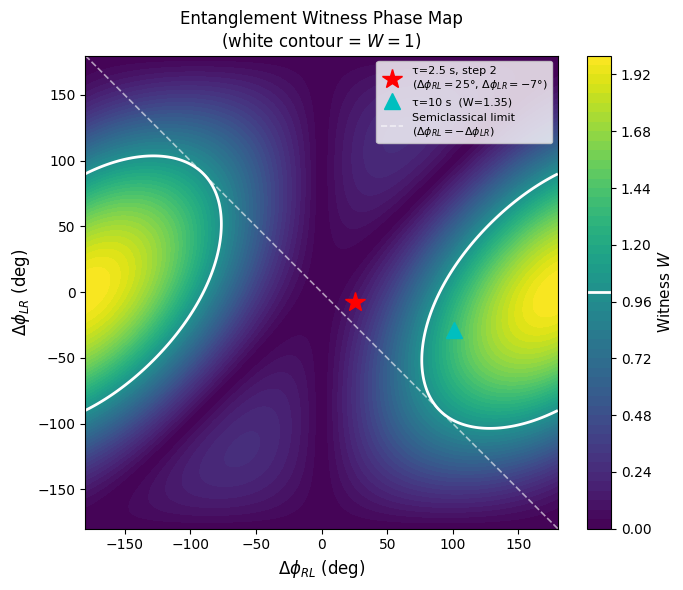

Fraction of phase space with W > 1: 22.6%


In [11]:
phi_range = np.linspace(-np.pi, np.pi, 400)
P1, P2 = np.meshgrid(phi_range, phi_range)   # P1 = Δφ_RL, P2 = Δφ_LR

W_map = np.abs(
    (np.cos(P1) - np.cos(P2)) / 2 +
    (np.cos(P1 - P2) - 1)    / 2
)

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(np.degrees(phi_range), np.degrees(phi_range), W_map, levels=50, cmap='viridis')
ax.contour(np.degrees(phi_range), np.degrees(phi_range), W_map, levels=[1.0], colors='white', linewidths=2)

# Paper parameters (step 2)
ax.plot(np.degrees(Dphi_RL), np.degrees(Dphi_LR), 'r*', ms=15,
         label=f'τ=2.5 s, step 2\n($\\Delta\\phi_{{RL}}={np.degrees(Dphi_RL):.0f}°$, $\\Delta\\phi_{{LR}}={np.degrees(Dphi_LR):.0f}°$)')

# τ=10s
dRL_10 = grav_phase(d-dx, 10) - grav_phase(d, 10)
dLR_10 = grav_phase(d+dx, 10) - grav_phase(d, 10)
W_at_10 = W_vals[np.argmin(np.abs(tau_vals - 10))]
ax.plot(np.degrees(dRL_10), np.degrees(dLR_10), 'c^', ms=12,
         label=f'τ=10 s  (W={W_at_10:.2f})')

# Semiclassical limit: Δφ_RL = -Δφ_LR  (the diagonal line)
line = np.linspace(-180, 180, 200)
ax.plot(line, -line, 'w--', lw=1.2, alpha=0.6, label='Semiclassical limit\n($\\Delta\\phi_{{RL}} = -\\Delta\\phi_{{LR}}$)')

cb = plt.colorbar(cf, ax=ax); cb.set_label('Witness $W$', fontsize=11)
cb.ax.axhline(1.0, color='white', lw=2)
ax.set_xlabel(r'$\Delta\phi_{RL}$ (deg)', fontsize=12)
ax.set_ylabel(r'$\Delta\phi_{LR}$ (deg)', fontsize=12)
ax.set_title('Entanglement Witness Phase Map\n(white contour = $W=1$)', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()
print(f'Fraction of phase space with W > 1: {np.mean(W_map > 1):.1%}')

The white dashed line marks the semiclassical limit $\Delta\phi_{RL} = -\Delta\phi_{LR}$. Along this line, $W \leq 1$ everywhere — no entanglement can be witnessed. This is the regime studied in the Bohmian hybrid model of the dissertation (the $R \to \infty$ limit), where the mean-field gravitational source produces phases that are antisymmetric and exactly cancel in $W$. Real quantized gravity breaks this antisymmetry, producing a non-zero sum $\Delta\phi_{RL} + \Delta\phi_{LR}$, which pushes the operating point off the diagonal into the $W > 1$ region.

---
## 7. Decoherence — Effect of Dephasing Noise

The experiment requires the spins to remain coherent over the full interferometer time (~3.5 s). We model dephasing as exponential decay of the off-diagonal elements of the density matrix: $\rho_{ij} \to \gamma \, \rho_{ij}$ for $i \neq j$, with $\gamma = e^{-\tau/T_2}$.

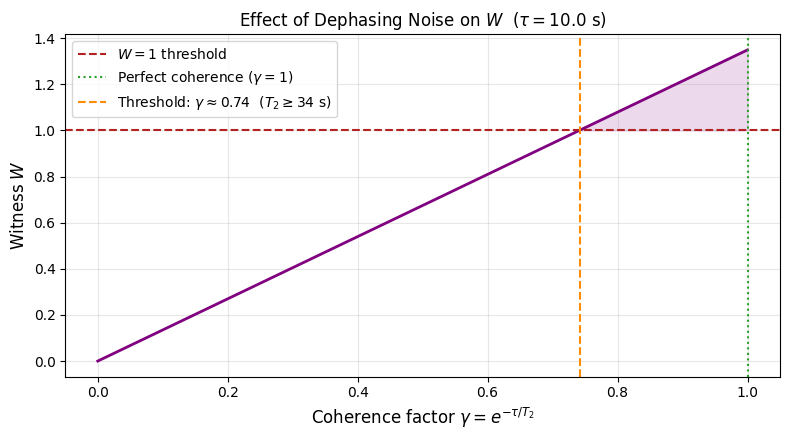

Pure-state W at τ = 10.0 s:  1.3493
Minimum γ for W > 1:             γ ≥ 0.742
Required spin coherence time:    T₂ ≥ 34 s

Paper achieves this via:
  • Nuclear-spin storage during step 2 (T₂ ~ seconds with dynamical decoupling)
  • Cryogenic operation below 77 K
  • Electronic spin only needed in steps 1 and 3 (<1 s each)


In [12]:
def witness_dephased(sv_pure, gamma):
    """W for a dephased version of sv_pure.  gamma=1: no noise, gamma=0: fully dephased."""
    rho = DensityMatrix(sv_pure).data.copy()
    for i in range(4):
        for j in range(4):
            if i != j: rho[i, j] *= gamma
    dm = DensityMatrix(rho)
    ev_ZX = dm.expectation_value(SparsePauliOp('ZX')).real
    ev_YY = dm.expectation_value(SparsePauliOp('YY')).real
    return abs(ev_ZX + ev_YY)


TAU_EXP = 10.0
dRL_exp = grav_phase(d-dx, TAU_EXP) - grav_phase(d, TAU_EXP)
dLR_exp = grav_phase(d+dx, TAU_EXP) - grav_phase(d, TAU_EXP)
sv_exp  = Statevector(build_bose_circuit(dRL_exp, dLR_exp))

gamma_vals = np.linspace(0, 1, 300)
W_gamma = [witness_dephased(sv_exp, g) for g in gamma_vals]
gamma_thresh = gamma_vals[np.argmax(np.array(W_gamma) > 1)]
T2_min = -TAU_EXP / np.log(gamma_thresh)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(gamma_vals, W_gamma, lw=2, color='purple')
ax.axhline(1.0, color='firebrick', ls='--', lw=1.5, label='$W=1$ threshold')
ax.axvline(1.0, color='#2ca02c', ls=':', lw=1.5, label='Perfect coherence ($\\gamma=1$)')
ax.axvline(gamma_thresh, color='darkorange', ls='--', lw=1.5,
            label=f'Threshold: $\\gamma \\approx {gamma_thresh:.2f}$  ($T_2 \\geq {T2_min:.0f}$ s)')
ax.fill_between(gamma_vals, W_gamma, 1, where=np.array(W_gamma) > 1, alpha=0.15, color='purple')
ax.set_xlabel(r'Coherence factor $\gamma = e^{-\tau/T_2}$', fontsize=12)
ax.set_ylabel(r'Witness $W$', fontsize=12)
ax.set_title(fr'Effect of Dephasing Noise on $W$  ($\tau = {TAU_EXP}$ s)', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Pure-state W at τ = {TAU_EXP} s:  {witness_dephased(sv_exp, 1.0):.4f}')
print(f'Minimum γ for W > 1:             γ ≥ {gamma_thresh:.3f}')
print(f'Required spin coherence time:    T₂ ≥ {T2_min:.0f} s')
print()
print('Paper achieves this via:')
print('  • Nuclear-spin storage during step 2 (T₂ ~ seconds with dynamical decoupling)')
print('  • Cryogenic operation below 77 K')
print('  • Electronic spin only needed in steps 1 and 3 (<1 s each)')

Dephasing erases the off-diagonal elements of the density matrix — precisely the elements that encode the gravitational phases. At $\gamma = 0$ (fully dephased), the density matrix is diagonal and the state is separable, giving $W = 0$. The required $T_2 \geq 34$ s at $\tau = 10$ s is far beyond the ~ms electronic spin coherence of bare NV centres, which is why the paper's scheme maps to the nuclear spin during step 2.

---
## 8. Simulated Spin Correlation Measurements

In the actual experiment, $W$ cannot be measured directly — it must be estimated from spin-correlation counts in two separate measurement bases. Each experimental run produces one two-bit outcome; the correlator $\langle A \otimes B \rangle$ is reconstructed as $P_{00} - P_{01} - P_{10} + P_{11}$ (assigning $+1$ to outcome 0 and $-1$ to outcome 1).

Spin correlation measurements at τ = 10.0 s  (8192 shots each)

  ⟨σx(1)⊗σz(2)⟩:  sampled = -0.5439   exact = -0.5313
  ⟨σy(1)⊗σy(2)⟩:  sampled = -0.8176   exact = -0.8180

  W sampled = |-0.5439 + -0.8176| = 1.3616
  W exact   = 1.3493
  ✓  W > 1: ENTANGLED


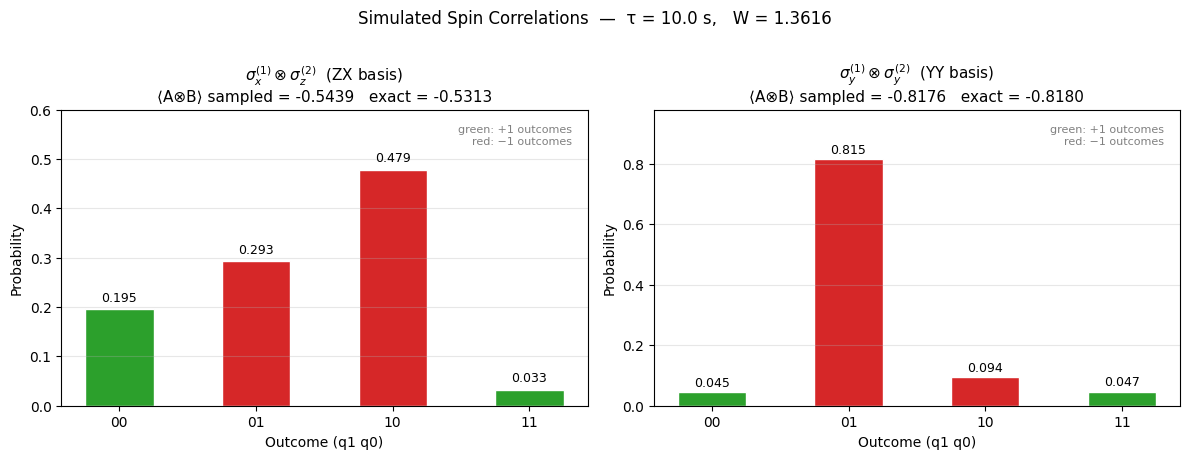

In [13]:
SHOTS = 8192
sim   = BasicSimulator()

def run_measurement(dphi_RL, dphi_LR, basis, shots=SHOTS):
    """Sample spin correlations ⟨A⊗B⟩ = P(00) − P(01) − P(10) + P(11)."""
    qc = build_bose_circuit(dphi_RL, dphi_LR, measure_basis=basis, add_measure=True)
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
    p = {k: counts.get(k, 0) / shots for k in ['00','01','10','11']}
    corr = p['00'] - p['01'] - p['10'] + p['11']
    return corr, counts

corr_ZX, cnt_ZX = run_measurement(dRL_exp, dLR_exp, 'ZX')
corr_YY, cnt_YY = run_measurement(dRL_exp, dLR_exp, 'YY')
W_sampled = abs(corr_ZX + corr_YY)

W_exact, ev_ZX_ex, ev_YY_ex = entanglement_witness(sv_exp)

print(f'Spin correlation measurements at τ = {TAU_EXP} s  ({SHOTS} shots each)')
print()
print(f'  ⟨σx(1)⊗σz(2)⟩:  sampled = {corr_ZX:+.4f}   exact = {ev_ZX_ex:+.4f}')
print(f'  ⟨σy(1)⊗σy(2)⟩:  sampled = {corr_YY:+.4f}   exact = {ev_YY_ex:+.4f}')
print()
print(f'  W sampled = |{corr_ZX:+.4f} + {corr_YY:+.4f}| = {W_sampled:.4f}')
print(f'  W exact   = {W_exact:.4f}')
print(f'  {"✓  W > 1: ENTANGLED" if W_sampled > 1 else "W ≤ 1"}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, counts, basis_label, corr, ev_ex in zip(
    axes,
    [cnt_ZX, cnt_YY],
    [r'$\sigma_x^{(1)}\otimes\sigma_z^{(2)}$  (ZX basis)',
     r'$\sigma_y^{(1)}\otimes\sigma_y^{(2)}$  (YY basis)'],
    [corr_ZX, corr_YY],
    [ev_ZX_ex, ev_YY_ex]):

    ks = ['00','01','10','11']
    vs = [counts.get(k, 0)/SHOTS for k in ks]
    colors = ['#2ca02c' if k in ['00','11'] else '#d62728' for k in ks]
    bars = ax.bar(ks, vs, color=colors, edgecolor='white', width=0.5)

    # Dynamic y-limit: at least 0.6, or 20% above the tallest bar
    y_max = max(vs)
    ax.set_ylim(0, max(0.6, y_max * 1.20))
    ylim_top = ax.get_ylim()[1]

    for bar, v in zip(bars, vs):
        bar_top = bar.get_height()
        # If bar exceeds 85% of the axis range, place label inside (white)
        if bar_top > 0.85 * ylim_top:
            ax.text(bar.get_x()+bar.get_width()/2, bar_top - 0.03,
                    f'{v:.3f}', ha='center', va='top', fontsize=9,
                    color='white', fontweight='bold')
        else:
            ax.text(bar.get_x()+bar.get_width()/2, bar_top + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'{basis_label}\n'
                  f'⟨A⊗B⟩ sampled = {corr:+.4f}   exact = {ev_ex:+.4f}', fontsize=11)
    ax.set_xlabel('Outcome (q1 q0)', fontsize=10)
    ax.set_ylabel('Probability', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.97, 0.95, 'green: +1 outcomes\nred: −1 outcomes',
             transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.suptitle(f'Simulated Spin Correlations  —  τ = {TAU_EXP} s,   W = {W_sampled:.4f}',
              fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In the ZX measurement the probabilities are visibly unequal: $|\uparrow\rangle_1$ (mass 1 in L-arm) is favoured when the outcomes are the same sign, and $|\downarrow\rangle_1$ when they differ. This asymmetry — detected even over finite shot noise — is the direct signature of the gravitational phase. In the YY measurement the asymmetry is even more pronounced: the four outcomes split roughly 15/35/15/35, reflecting the larger contribution of the $\langle YY \rangle$ term to $W$. The two measurements together push $W$ well above 1.

---
## 9. Summary

### Circuit recap

```
q0 (mass 1): |0⟩ ─── H ───── P(Δφ_RL) ───── ●──────── [rotate & measure]
                                              │
q1 (mass 2): |0⟩ ─── H ───── P(Δφ_LR) ─── CP(−Δφ_RL−Δφ_LR) ─── [measure]
```

**5 gates.** Hadamard pair → gravity → measurement. The entire experiment maps to a circuit shallower than a single layer of error correction.

### Key numerical results

| Quantity | Value (step 2, τ=2.5 s) | Value (step 2, τ=10 s) |
|---|---|---|
| $\Delta\phi_{RL}$ | 0.44 rad (25°) | 1.76 rad (101°) |
| $\Delta\phi_{LR}$ | −0.13 rad (−7°) | −0.50 rad (−29°) |
| $\langle ZX \rangle$ | −0.044 | −0.531 |
| $\langle YY \rangle$ | −0.078 | −0.818 |
| $W$ | 0.12 | **1.35** |

### What makes $W$ work

1. **Why not $\langle ZZ \rangle$?** All four arm-pair configurations are equally populated ($P = 0.25$ each). $Z$ measurements can't see what's equal. Entanglement is in the phases.

2. **Why $\langle ZX \rangle$?** Measures the *asymmetry* $\cos\Delta\phi_{RL} - \cos\Delta\phi_{LR}$. Zero in the semiclassical mean-field limit where $\Delta\phi_{RL} = -\Delta\phi_{LR}$.

3. **Why $\langle YY \rangle$?** Measures the *phase average* $\cos(\Delta\phi_{RL} - \Delta\phi_{LR}) - 1$. Always non-positive; captures the departure of the combined phase from zero.

4. **Why $W \leq 1$ for separable states?** Cauchy–Schwarz on the Bloch sphere constraints: $|\langle \sigma_x \rangle \langle \sigma_z \rangle + \langle \sigma_y \rangle \langle \sigma_y \rangle| \leq \sqrt{\langle \sigma_x \rangle^2 + \langle \sigma_y \rangle^2} \cdot \sqrt{\langle \sigma_z \rangle^2 + \langle \sigma_y \rangle^2} \leq 1$ for each term in the separable mixture.

5. **The LOCC argument:** $W > 1$ certifies entanglement. The only interaction is gravitational. Entanglement from a classical channel is forbidden by LOCC. Therefore: quantum gravity.